In [1]:
import os
import csv
import datetime as dt
import pandas as pd

# index를 날짜로 하는 데이터프레임을 price, adj_price, divend에 대해 반환
def extract_stock_data(file_path, ticker):
    extract_datas = []

    with open(os.path.join(file_path, ticker + '.csv'), newline='') as csvfile:
        reader = csv.reader(csvfile)

        for row in reader:
            extract_datas.append(row)
        
    price_dates = list(map(dt.date.fromisoformat, extract_datas[0]))
    price_history = list(map(float, extract_datas[1]))
    adj_price_dates = list(map(dt.date.fromisoformat, extract_datas[2]))
    adj_price_history = list(map(float, extract_datas[3]))
    divend_dates = list(map(dt.date.fromisoformat, extract_datas[4]))
    divend_history = list(map(float, extract_datas[5]))

    price_df = pd.DataFrame({'date': price_dates, 'price': price_history})
    adj_price_df = pd.DataFrame({'date': adj_price_dates, 'adj_price': adj_price_history})
    divend_df = pd.DataFrame({'date': divend_dates, 'divend': divend_history})

    price_df.set_index('date', inplace=True)
    adj_price_df.set_index('date', inplace=True)
    divend_df.set_index('date', inplace=True)

    return (price_df, adj_price_df, divend_df)

def make_stock_data(file_path, tickers):
    stock_data = []

    for ticker in tickers:
        price_df, adj_price_df, divend_df = extract_stock_data(file_path, ticker)
        stock_df = pd.concat([price_df, adj_price_df, divend_df], axis=1, sort=True)
        stock_df.columns = pd.MultiIndex.from_product([[ticker], stock_df.columns])
        stock_data.append(stock_df)

    stock_data = pd.concat(stock_data, axis=1, sort=True)

    return stock_data


In [2]:
from portfolio import Portfolio

# stock 불러와서 데이터프레임화 하기
file_path = './etf'
tickers = ['QQQ', 'DGRW', 'SCHD', 'SPY', 'SCHG', 'SPYG']
stock_data = make_stock_data(file_path, tickers)
pd.options.display.float_format = '{:.2f}'.format

# test_stock = Portfolio(make_stock_data(file_path, ['QQQ', 'SCHG']), 10000)
test_stock = Portfolio(stock_data, 10000)
portfolio = Portfolio(stock_data, 10000, {"QQQ":56, "SCHD":24, "DGRW":20})

In [3]:
alpha_beta = test_stock.stock_alphabeta(stock_data[('QQQ', 'adj_price')], risk_free_rate=0.02)
pd.concat([test_stock.stock_cagr(), test_stock.stock_stdev(), test_stock.stock_mdd(), alpha_beta], axis=0)

,SCHD,SPY,SCHG,QQQ,SPYG,DGRW
cagr,12.14,14.22,17.08,20.17,16.58,13.13
stdev,15.81,16.99,20.07,20.97,19.28,15.52
mdd,33.33,33.72,34.59,35.12,32.67,32.04
alpha,0.51,-1.31,-1.57,-0.01,-1.41,-0.36
beta,0.54,0.76,0.93,1.00,0.90,0.64


In [4]:
test_stock.stock_corr()

,SCHD,SPY,SCHG,QQQ,SPYG,DGRW
SCHD,1.00,0.88,0.74,0.72,0.76,0.93
SPY,0.88,1.00,0.96,0.93,0.97,0.97
SCHG,0.74,0.96,1.00,0.98,0.99,0.89
QQQ,0.72,0.93,0.98,1.00,0.97,0.87
SPYG,0.76,0.97,0.99,0.97,1.00,0.90
DGRW,0.93,0.97,0.89,0.87,0.90,1.00


In [162]:
portfolio.backtest(rebalancing_cycle=5, benchmark=stock_data[('QQQ', 'adj_price')])

(           rebalancing    total    cash           QQQ                         \
                   flag    value   value weight  price number    value weight   
 date                                                                           
 2013-05-22        True    10000       0      0  73.62  76.07  5600.00  56.00   
 2013-05-23       False  9974.26    0.00   0.00  73.45  76.07  5587.07  56.01   
 2013-05-24       False  9975.47    0.00   0.00  73.41  76.07  5584.03  55.98   
 2013-05-28       False 10043.75    0.00   0.00  73.89  76.07  5620.54  55.96   
 2013-05-29       False  9972.07    0.00   0.00  73.54  76.07  5593.91  56.10   
 ...                ...      ...     ...    ...    ...    ...      ...    ...   
 2026-05-18       False 75103.65 -913.23  -1.22 705.88  61.61 43485.88  57.90   
 2026-05-19       False 74794.39 -913.23  -1.22 701.53  61.61 43217.89  57.78   
 2026-05-20       False 75611.19 -913.23  -1.21 713.15  61.61 43933.75  58.10   
 2026-05-21       False 7578

In [5]:
def calc_target_ratio(base_ratio:tuple, etc_ratio:tuple) -> tuple:
    base_sum = sum(base_ratio)
    qqq = base_ratio[0] / base_sum * 100
    etc_sum = sum(etc_ratio)
    etc1 = (etc_ratio[0] / etc_sum) * (base_ratio[1] / base_sum) * 100
    etc2 = (etc_ratio[1] / etc_sum) * (base_ratio[1] / base_sum) * 100

    return (round(qqq, 1), round(etc1, 1), round(etc2, 1))

In [12]:
from joblib import Parallel, delayed
from portfolio_test import portfolio_backtest_by_duration

stats = pd.DataFrame(columns=['cagr', 'stdev', 'mdd', 'beta', 'alpha'])

param_list = []
for qqq_weight in range(0, 100, 5):
    for schd_weight in range(0, 10):
        ratio_qqq_etc = (qqq_weight, 100 - qqq_weight)
        ratio_schd_dgrw = (schd_weight, 10 - schd_weight)
        ratio_qqq_schd_dgrw = calc_target_ratio(ratio_qqq_etc, ratio_schd_dgrw)
        
        target_ratio = {
            'QQQ': ratio_qqq_schd_dgrw[0],
            'SCHD': ratio_qqq_schd_dgrw[1],
            'DGRW': ratio_qqq_schd_dgrw[2]
        }
        print(target_ratio)    
        p = Portfolio(stock_data, 10000, target_ratio)
        param_list.append((p, stock_data[('QQQ', 'adj_price')], 5))

with Parallel(n_jobs=-1) as parallel:
        results = parallel(delayed(portfolio_backtest_by_duration)(*params) for params in param_list)
        
for stat in results:
    stats = pd.concat([stats, stat])

stats

{'QQQ': 0.0, 'SCHD': 0.0, 'DGRW': 100.0}
{'QQQ': 0.0, 'SCHD': 10.0, 'DGRW': 90.0}
{'QQQ': 0.0, 'SCHD': 20.0, 'DGRW': 80.0}
{'QQQ': 0.0, 'SCHD': 30.0, 'DGRW': 70.0}
{'QQQ': 0.0, 'SCHD': 40.0, 'DGRW': 60.0}
{'QQQ': 0.0, 'SCHD': 50.0, 'DGRW': 50.0}
{'QQQ': 0.0, 'SCHD': 60.0, 'DGRW': 40.0}
{'QQQ': 0.0, 'SCHD': 70.0, 'DGRW': 30.0}
{'QQQ': 0.0, 'SCHD': 80.0, 'DGRW': 20.0}
{'QQQ': 0.0, 'SCHD': 90.0, 'DGRW': 10.0}
{'QQQ': 5.0, 'SCHD': 0.0, 'DGRW': 95.0}
{'QQQ': 5.0, 'SCHD': 9.5, 'DGRW': 85.5}
{'QQQ': 5.0, 'SCHD': 19.0, 'DGRW': 76.0}
{'QQQ': 5.0, 'SCHD': 28.5, 'DGRW': 66.5}
{'QQQ': 5.0, 'SCHD': 38.0, 'DGRW': 57.0}
{'QQQ': 5.0, 'SCHD': 47.5, 'DGRW': 47.5}
{'QQQ': 5.0, 'SCHD': 57.0, 'DGRW': 38.0}
{'QQQ': 5.0, 'SCHD': 66.5, 'DGRW': 28.5}
{'QQQ': 5.0, 'SCHD': 76.0, 'DGRW': 19.0}
{'QQQ': 5.0, 'SCHD': 85.5, 'DGRW': 9.5}
{'QQQ': 10.0, 'SCHD': 0.0, 'DGRW': 90.0}
{'QQQ': 10.0, 'SCHD': 9.0, 'DGRW': 81.0}
{'QQQ': 10.0, 'SCHD': 18.0, 'DGRW': 72.0}
{'QQQ': 10.0, 'SCHD': 27.0, 'DGRW': 63.0}
{'QQQ': 10.0, 'SC

,cagr,stdev,mdd,beta,alpha,ratio
0,12.51,11.81,13.22,0.69,-1.09,0.0:0.0:100.0
1,10.19,12.60,18.26,0.66,-0.94,0.0:0.0:100.0
2,8.06,17.78,31.13,0.76,-4.65,0.0:0.0:100.0
3,16.44,17.67,31.29,0.70,-1.96,0.0:0.0:100.0
4,12.26,18.54,31.77,0.66,0.46,0.0:0.0:100.0
...,...,...,...,...,...,...
4,16.38,23.48,28.24,0.97,0.14,95.0:4.5:0.5
5,15.38,25.23,33.64,0.97,-0.00,95.0:4.5:0.5
6,20.45,24.63,33.76,0.97,-0.02,95.0:4.5:0.5
7,17.39,22.61,33.70,0.96,0.17,95.0:4.5:0.5


In [13]:
stats.to_csv('./stats_qqq_schd_dgrw.csv')

In [ ]:
stat_summary = stats.groupby(['ratio']).mean()
stat_summary

In [ ]:
qqq = Portfolio(stock_data, 10000, {"QQQ":100})
test = Portfolio(stock_data, 10000, {"QQQ":56, "SCHD":24, "DGRW":20})
qqq_stat = portfolio_backtest_by_duration(qqq, duration=5, start_date=test.start_date)
qqq_stat

In [ ]:
pd.set_option('display.max_rows', None)

stat_summary_sorted = stat_summary.sort_values(by=['alpha'], ascending=False)
stat_sorted = stats.sort_values(by=['ratio', 'alpha'], ascending=[True, False])
test = stats[(stats['ratio'] == '50.0:35.0:15.0') | (stats['ratio'] == '80.0:16.0:4.0')]
test.sort_index(inplace=True)

test



In [ ]:
stat_summary_sorted

In [ ]:
stat_sorted

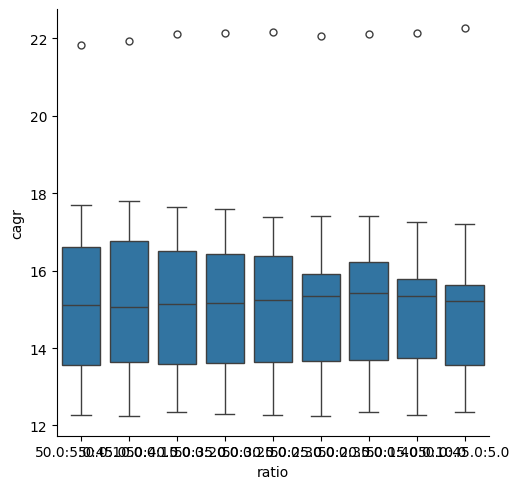

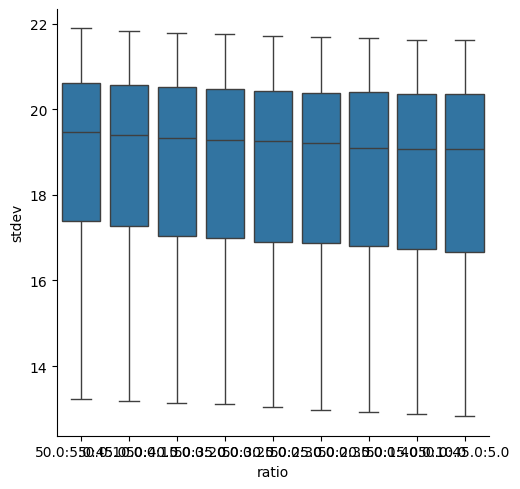

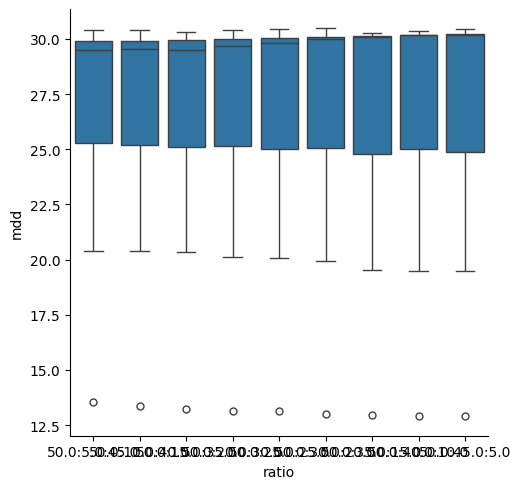

In [11]:
import seaborn as sns

sns.catplot(data=stats, x='ratio', y='cagr', kind='box')
sns.catplot(data=stats, x='ratio', y='stdev', kind='box')
sns.catplot(data=stats, x='ratio', y='mdd', kind='box')

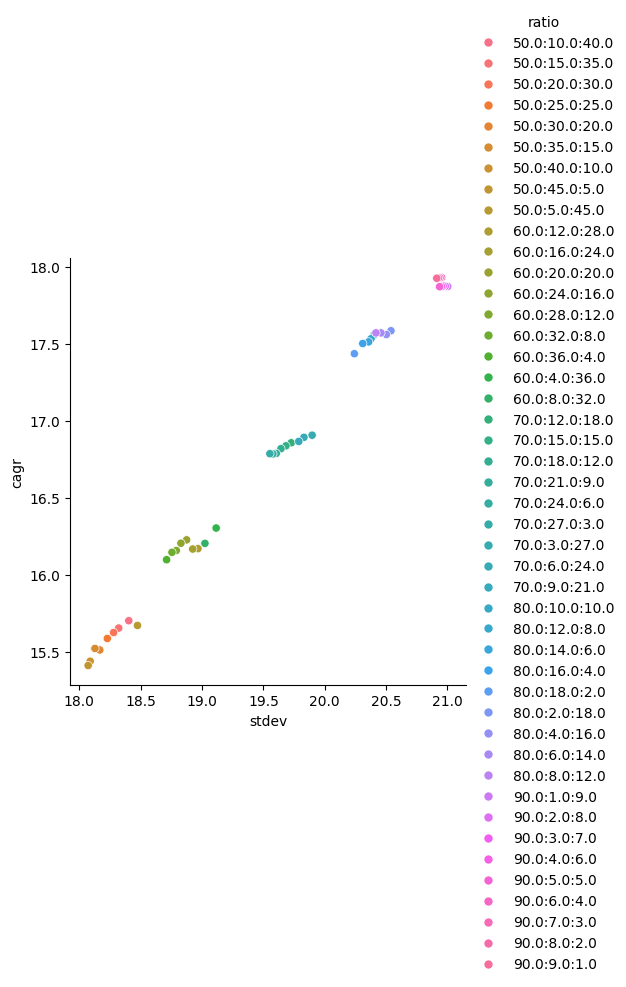

In [17]:
sns.relplot(data=stat_summary, x='stdev', y='cagr', hue='ratio')

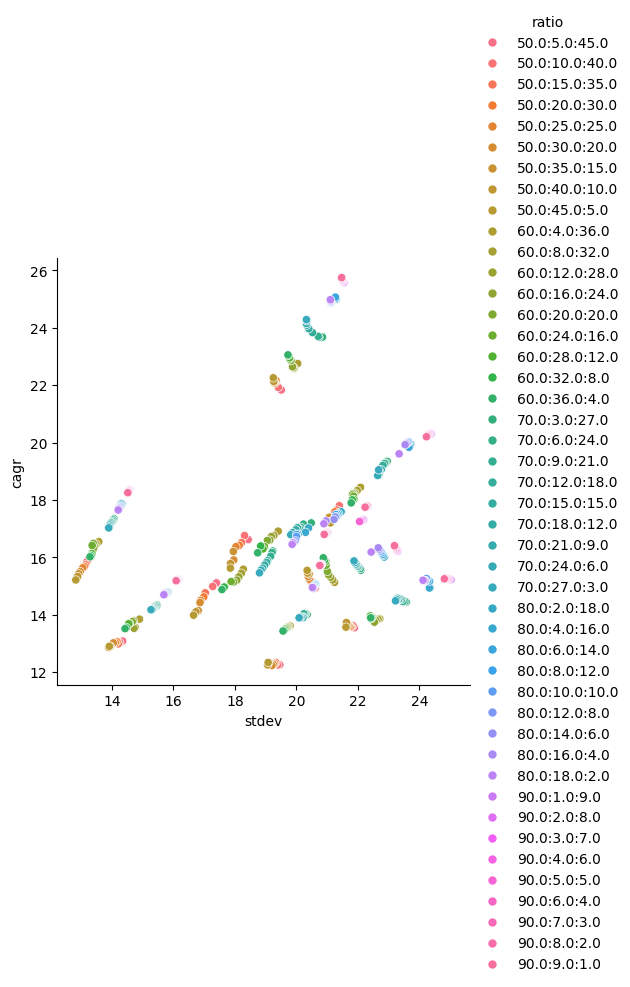

In [33]:
sns.relplot(data=stats, x='stdev', y='cagr', hue='ratio')